In [2]:
import matplotlib
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from io import StringIO
import numpy.ma as ma
from simpledbf import Dbf5

PyTables is not installed. No support for HDF output.
SQLalchemy is not installed. No support for SQL output.


In [3]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w

In [4]:
# Raw data as a string
data = """
abbre,ssp126,ssp245,ssp370,ssp585
hsg, 	2020,	2019,	2021,	2021
dsk,	2026,	2027,	2029,	2032
xhl,	2042,	2053,	2055,	2049
slglk,	2042,	2054,	2056,	2058
kq,		2055,	2077,	2074,	2078
wlwt,	2064,	2077,	2093,	2084
tgzlk,	2069,	2080,	2094,	2094
"""

# Use StringIO to simulate a file
data_io = StringIO(data)

# Read the data into a DataFrame
peak_water_df = pd.read_csv(data_io,index_col=0)

# Display the DataFrame
print(peak_water_df)

       ssp126  ssp245  ssp370  ssp585
abbre                                
hsg      2020    2019    2021    2021
dsk      2026    2027    2029    2032
xhl      2042    2053    2055    2049
slglk    2042    2054    2056    2058
kq       2055    2077    2074    2078
wlwt     2064    2077    2093    2084
tgzlk    2069    2080    2094    2094


In [5]:
# from dbf import from_dataframe, DBF
# Path to the .dbf file
dbf_path = r"C:\Users\HP\Documents\ArcGIS\Projects\LSTM_pre0\Tarim_glacier_spatial_join.dbf"
dbf = Dbf5(dbf_path)

# Convert the .dbf file to a pandas DataFrame
RGIdf  = dbf.to_dataframe()
RGIdf.set_index('RGIId', inplace=True)

In [6]:
# # from dbf import from_dataframe, DBF
# # Path to the .dbf file
# dbf_path = r"C:\Users\HP\Documents\ArcGIS\Projects\LSTM_pre0\c13_rgi60_SpatialJoin.dbf"
# dbf = Dbf5(dbf_path)
#
# # Convert the .dbf file to a pandas DataFrame
# RGIdf  = dbf.to_dataframe()
# RGIdf.set_index('RGIId', inplace=True)
# RGIdf[RGIdf['abbre'] == 'kq']

In [7]:
RGIdf[['Area','abbre']].groupby('abbre').sum()

,Area
abbre,
dsk,411.179
hsg,24.622
kq,9952.470
slglk,761.533
tgzlk,4316.084
wlwt,2161.683
xhl,3437.248


In [8]:
# RGIdf = RGIdf['abbre']

In [12]:
os.chdir("K:\GlacierData")
outputpath = f"F:\geodata\\river_runoff_obs\\"

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\g'
C:\Users\HP\AppData\Local\Temp\ipykernel_84680\1883420435.py:1: SyntaxWarning: invalid escape sequence '\G'
  os.chdir("K:\GlacierData")
C:\Users\HP\AppData\Local\Temp\ipykernel_84680\1883420435.py:2: SyntaxWarning: invalid escape sequence '\g'
  outputpath = f"F:\geodata\\river_runoff_obs\\"


In [13]:
color_list =  ['#00008B','#FFA500','#FF0000','#B22222']
stations = ['hsg', 'dsk', 'xhl', 'slglk', 'kq', 'wlwt', 'tgzlk']

In [14]:
# for scenario in ["ssp" + str(x) for x in [126,245, 370, 585]]:
#     runoff_part_list = [] # list collecting monthly runoff of each basin in each climate model
#     RGIId_part_list = []
#     fnlist= ["R13_glac_runoff_fixed_monthly_1set_2000_2100-%s-Batch-%d-%d000.nc" % (scenario,1000*i+1, i+1) for i in range(
#     55)]
#     for fn in fnlist:
#         print(fn)
#         # fn = "R13_glac_runoff_fixed_monthly_1set_2000_2100-ssp126-Batch-1-1000.nc"
#         ds = nc.Dataset(fn, "r")
#         runoff_part = ma.getdata(ds.variables["glac_runoff_fixed_monthly"][:] )  # Access the variable
#         RGIId_part = ma.getdata(ds.variables["RGIId"][:] )
# 
#         runoff_part = runoff_part.reshape(
#             (12, RGIId_part.shape[0], 101, 12))  # The 4-D includes climate models, glaciers, years and months
#         runoff_anl_part = runoff_part.sum(axis=3)
# 
#         runoff_part_list.append(runoff_anl_part.astype(int))
#         RGIId_part_list.append(RGIId_part)
# 
# 
#     runoff_anl_arr = np.concatenate(runoff_part_list,axis=1)
#     RGIId_arr = np.concatenate(RGIId_part_list,axis=0)
# 
#     std_runoff_anl_arr = runoff_anl_arr.std(axis = 0)
#     mean_runoff_anl_arr = runoff_anl_arr.mean(axis = 0)
#     
#     std_runoff_anl_df = pd.DataFrame(std_runoff_anl_arr, index=RGIId_arr, columns=list(range(2000, 2101)))
#     std_runoff_anl_df = RGIdf.merge(std_runoff_anl_df,left_index=True,right_index = True)
#     
#     mean_runoff_anl_df = pd.DataFrame(mean_runoff_anl_arr, index=RGIId_arr, columns=list(range(2000, 2101)))
#     mean_runoff_anl_df = RGIdf.merge(mean_runoff_anl_df,left_index=True,right_index = True)
# 
#     station_runoff_anl_df =mean_runoff_anl_df[list(range(2000, 2101))+['abbre']].groupby('abbre').sum()
#     station_runoff_anl_df['scenario'] = scenario
#     station_runoff_anl_df = station_runoff_anl_df[list(range(2000, 2101))+['scenario']]
#     station_runoff_anl_df.to_csv(os.path.join(outputpath, scenario+"_station_runoff_mean.csv"))
#     
#     std_sqrd_runoff_anl_df =std_runoff_anl_df; std_sqrd_runoff_anl_df[list(range(2000, 2101))] = std_sqrd_runoff_anl_df[list(range(2000, 2101))].pow(2)
#     std_region_runoff_anl_df = std_sqrd_runoff_anl_df[list(range(2000, 2101))+['abbre']].groupby(['abbre']).sum().pow(0.5)
#     std_region_runoff_anl_df.to_csv(os.path.join(outputpath, scenario+"_station_runoff_std.csv"))

In [15]:
combined_station_runoff_anl_df = pd.concat((pd.read_csv(outputpath+'test1\\'+file) for file in ['ssp126_station_runoff_mean.csv', 'ssp245_station_runoff_mean.csv',
         'ssp370_station_runoff_mean.csv', 'ssp585_station_runoff_mean.csv']), ignore_index=True)
combined_station_runoff_anl_df.to_csv(outputpath+'annual_station_runoff.csv')

In [16]:
# Add scenario columns
for scenario in ["ssp" + str(x) for x in [126,245, 370, 585]]:
    std_sce_df = pd.read_csv(r"F:\geodata\river_runoff_obs\test1\%s_station_runoff_std.csv" % scenario ,index_col=['abbre'])
    std_sce_df["scenario"] = scenario
    std_sce_df.to_csv(r"F:\geodata\river_runoff_obs\test1\%s_station_runoff_std.csv" % scenario )

In [17]:
import pandas as pd

# Load the data
annual_region_runoff = pd.read_csv(outputpath + 'annual_station_runoff.csv')

# Group by 'abbre'
groups = annual_region_runoff.groupby('abbre')

# Define the desired order of stations
stations = ['hsg', 'dsk', 'xhl', 'slglk', 'kq', 'wlwt', 'tgzlk']

# Create a categorical type with the specified order
annual_region_runoff['abbre'] = pd.Categorical(annual_region_runoff['abbre'], categories=stations, ordered=True)

# Sort the DataFrame based on the categorical order
annual_region_runoff_sorted = annual_region_runoff.sort_values('abbre')

# Regroup the sorted DataFrame
groups = annual_region_runoff_sorted.groupby('abbre')


C:\Users\HP\AppData\Local\Temp\ipykernel_84680\3630913786.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = annual_region_runoff_sorted.groupby('abbre')


C:\Users\HP\AppData\Local\Temp\ipykernel_84680\1940479791.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if peak_water_year[i]!=2095:
C:\Users\HP\AppData\Local\Temp\ipykernel_84680\1940479791.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[ii].vlines(peak_water_year[i], 0, group[s][peak_water_year[i]]/group.loc[2000:2015,s].mean(), linestyles='dashed', colors=color_list[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_84680\1940479791.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFr

hsg ssp126 -11522066.166666666
hsg ssp245 -10533497.749999996
hsg ssp370 -10235313.416666662
hsg ssp585 -9066674.41666666
dsk ssp126 -132117447.0
dsk ssp245 -135575214.0
dsk ssp370 -124720912.83333331
dsk ssp585 -104438269.25
xhl ssp126 -37147392.91666651
xhl ssp245 -50091559.666666746
xhl ssp370 -117821793.91666675
xhl ssp585 -151155706.5
slglk ssp126 80614918.00000006
slglk ssp245 101871247.33333331
slglk ssp370 39373230.75000006
slglk ssp585 20704802.416666627
kq ssp126 99608737.75
kq ssp245 226899938.75
kq ssp370 329249567.5
kq ssp585 342030634.0833333
wlwt ssp126 365168415.9166666
wlwt ssp245 973601418.3333335
wlwt ssp370 1586164523.1666667
wlwt ssp585 1628308614.5833335
tgzlk ssp126 481691664.4166667
tgzlk ssp245 2099813964.1666665
tgzlk ssp370 4515590460.0
tgzlk ssp585 6282566370.416667
tgzlk


C:\Users\HP\AppData\Local\Temp\ipykernel_84680\1940479791.py:103: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


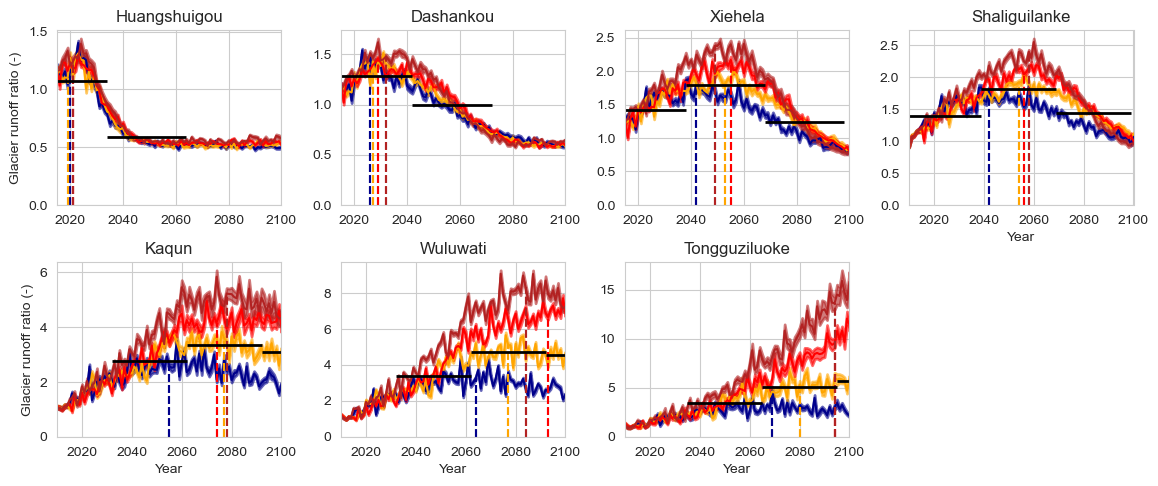

In [18]:
std_df = pd.concat(pd.read_csv(f"{outputpath}test1\\{scenario}_station_runoff_std.csv",index_col=['abbre']) for scenario in ["ssp" + str(x) for x in [126,245, 370, 585]])
std_grs = std_df.groupby('scenario')

station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 10

# Creating subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
# Flattening the axes array for easy iteration
axes = axes.flatten()
# fig.delaxes(axes[3, 3])  # axs[1, 1] refers to the bottom right axes

# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

ii=0

for RGI_CODE, group in groups:
    name = group['abbre'].unique()[0]
    std_region=std_df.loc[name,:]
    std_region.set_index('scenario', inplace = True)
    std_region = (std_region[[str(x) for x in range(2000,2101)]]).T
    # print(name,len(group),len(std_region))

    group=group.set_index("scenario")
    group = (group[[str(x) for x in range(2000,2101)]]).T
    group.index = list(range(2000,2101))
    group = group[['ssp126','ssp245','ssp370','ssp585']]

    std_region.index = list(range(2000,2101))

    peak_water_year = group.rolling(11).mean().idxmax() -6

    for i,s in enumerate(['ssp126','ssp245','ssp370','ssp585']):
        # Relative to the mean runoff of 2000-2015. Identified with Rounce et.al Future Mass Change in HMA
        axes[ii].fill_between(x = group.index, y1 =(group[s]+ std_region[s])/group.loc[2000:2015,s].mean(),y2=(group[s]- std_region[s])/group.loc[2000:2015,s].mean(),linewidth=2,interpolate=True,alpha = 0.6,color = color_list[i])
        # add peak water
        if peak_water_year[i]!=2095:
            axes[ii].vlines(peak_water_year[i], 0, group[s][peak_water_year[i]]/group.loc[2000:2015,s].mean(), linestyles='dashed', colors=color_list[i])
            axes[ii].vlines(peak_water_year[i], 0, group[s][peak_water_year[i]]/group.loc[2000:2015,s].mean(), linestyles='dashed', colors=color_list[i])

        #     print(name,s,group.loc[2000:2015,s].mean(),peak_water_year[i],group.loc[peak_water_year[i]-5:peak_water_year[i],s].mean(),group.loc[peak_water_year[i] :peak_water_year[i]+5,s].mean(),sep=',')
        # else:
        #     print(name,s,"wont occur")
        # # print(name,s,peak_water_year[i],  group[s][peak_water_year[0]]/group.loc[2000:2015,s].mean(),sep=",")

        print(name,s,group[s][2100]-group[s][2000])

        axes[ii].plot(group.index,group.loc[:,s ] / group.loc[2000:2015,s ].mean(),color=color_list[i])

    axes[ii].set_xlim([2015, 2100])
    axes[ii].set_ylim(bottom=0)
    axes[ii].set_title(station_names[ii])

    if ii>=3: # remove x labels
        axes[ii].set_xticks([2010,2020, 2030, 2040, 2050,2060,2070,2080,2090,2100], minor=True)
        axes[ii].set_xlabel("Year")

    if ii%4 == 0: # remove y labels
        axes[ii].set_ylabel("Glacier runoff ratio (-)")
    # axes[ii].legend('', frameon=False)    # plt.legend(title='scenario', loc='upper right')

    before_peak = group['ssp245'][
    (group.index >= peak_water_year['ssp245'] - 45) & (group.index < peak_water_year['ssp245']-15)
    ]/ group.loc[2000:2015,'ssp245'].mean()
    after_peak  = group['ssp245'][
        (group.index >= peak_water_year['ssp245'] + 15) & (group.index  < peak_water_year['ssp245']+45)
    ]/ group.loc[2000:2015,'ssp245'].mean()
    during_peak = group['ssp245'][
        (group.index >= peak_water_year['ssp245'] - 15) & (group.index  < peak_water_year['ssp245']+15)
    ]/ group.loc[2000:2015,'ssp245'].mean()

    axes[ii].hlines(y= before_peak.mean(),xmax = peak_water_year['ssp245']-45 , xmin= peak_water_year['ssp245']-15, color='black', linewidth=2)
    axes[ii].hlines(y= during_peak.mean(),xmax = peak_water_year['ssp245']+15 , xmin= peak_water_year['ssp245']-15, color='black', linewidth=2)
    axes[ii].hlines(y= after_peak.mean(),xmax = peak_water_year['ssp245']+45 , xmin= peak_water_year['ssp245']+15, color='black', linewidth=2)

    ii+=1

    # Remove y-axis labels for the 2nd column
    # if ii % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
    #     axes[ii].set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    # if i < len(axes) - 3:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
    #     axes[ii].set_xlabel('')  # Remove the x-axis label
    #     axes[ii].set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

fig.tight_layout()
fig.show()
print(name)
fig.savefig("F:\\geodata\\river_runoff_obs\\annual_glacier_runoff.svg")

C:\Users\HP\AppData\Local\Temp\ipykernel_84680\142039319.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if peak_water_year[i]!=2095:
C:\Users\HP\AppData\Local\Temp\ipykernel_84680\142039319.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[ii].vlines(peak_water_year[i], 0, group[s][peak_water_year[i]]/group.loc[2000:2015,s].mean(), linestyles='dashed', colors=color_list[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_84680\142039319.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame

hsg ssp126 -11522066.166666666
hsg ssp245 -10533497.749999996
hsg ssp370 -10235313.416666662
hsg ssp585 -9066674.41666666
dsk ssp126 -132117447.0
dsk ssp245 -135575214.0
dsk ssp370 -124720912.83333331
dsk ssp585 -104438269.25
xhl ssp126 -37147392.91666651
xhl ssp245 -50091559.666666746
xhl ssp370 -117821793.91666675
xhl ssp585 -151155706.5
slglk ssp126 80614918.00000006
slglk ssp245 101871247.33333331
slglk ssp370 39373230.75000006
slglk ssp585 20704802.416666627
kq ssp126 99608737.75
kq ssp245 226899938.75
kq ssp370 329249567.5
kq ssp585 342030634.0833333
wlwt ssp126 365168415.9166666
wlwt ssp245 973601418.3333335
wlwt ssp370 1586164523.1666667
wlwt ssp585 1628308614.5833335
tgzlk ssp126 481691664.4166667
tgzlk ssp245 2099813964.1666665
tgzlk ssp370 4515590460.0
tgzlk ssp585 6282566370.416667


C:\Users\HP\AppData\Local\Temp\ipykernel_84680\142039319.py:103: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


tgzlk


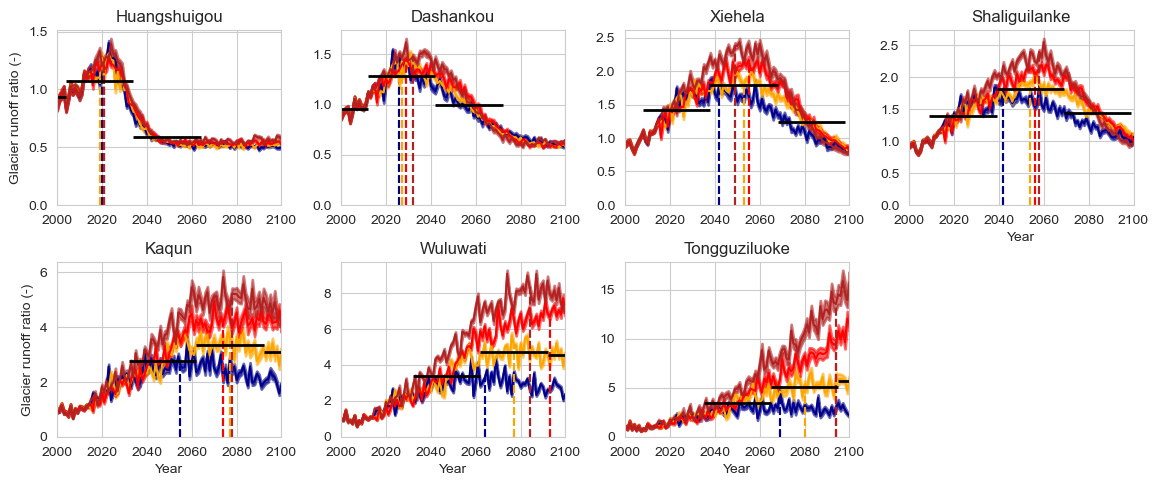

In [19]:
std_df = pd.concat(pd.read_csv(f"{outputpath}test1\\{scenario}_station_runoff_std.csv",index_col=['abbre']) for scenario in ["ssp" + str(x) for x in [126,245, 370, 585]])
std_grs = std_df.groupby('scenario')

station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 10

# Creating subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
# Flattening the axes array for easy iteration
axes = axes.flatten()
# fig.delaxes(axes[3, 3])  # axs[1, 1] refers to the bottom right axes

# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

ii=0

for RGI_CODE, group in groups:
    name = group['abbre'].unique()[0]
    std_region=std_df.loc[name,:]
    std_region.set_index('scenario', inplace = True)
    std_region = (std_region[[str(x) for x in range(2000,2101)]]).T
    # print(name,len(group),len(std_region))

    group=group.set_index("scenario")
    group = (group[[str(x) for x in range(2000,2101)]]).T
    group.index = list(range(2000,2101))
    group = group[['ssp126','ssp245','ssp370','ssp585']]

    std_region.index = list(range(2000,2101))

    peak_water_year = group.rolling(11).mean().idxmax() -6

    for i,s in enumerate(['ssp126','ssp245','ssp370','ssp585']):
        # Relative to the mean runoff of 2000-2015. Identified with Rounce et.al Future Mass Change in HMA
        axes[ii].fill_between(x = group.index, y1 =(group[s]+ std_region[s])/group.loc[2000:2015,s].mean(),y2=(group[s]- std_region[s])/group.loc[2000:2015,s].mean(),linewidth=2,interpolate=True,alpha = 0.6,color = color_list[i])
        # add peak water
        if peak_water_year[i]!=2095:
            axes[ii].vlines(peak_water_year[i], 0, group[s][peak_water_year[i]]/group.loc[2000:2015,s].mean(), linestyles='dashed', colors=color_list[i])
            axes[ii].vlines(peak_water_year[i], 0, group[s][peak_water_year[i]]/group.loc[2000:2015,s].mean(), linestyles='dashed', colors=color_list[i])

        #     print(name,s,group.loc[2000:2015,s].mean(),peak_water_year[i],group.loc[peak_water_year[i]-5:peak_water_year[i],s].mean(),group.loc[peak_water_year[i] :peak_water_year[i]+5,s].mean(),sep=',')
        # else:
        #     print(name,s,"wont occur")
        # # print(name,s,peak_water_year[i],  group[s][peak_water_year[0]]/group.loc[2000:2015,s].mean(),sep=",")

        print(name,s,group[s][2100]-group[s][2000])

        axes[ii].plot(group.index,group.loc[:,s ] / group.loc[2000:2015,s ].mean(),color=color_list[i])

    axes[ii].set_xlim([2000, 2100])
    axes[ii].set_ylim(bottom=0)
    axes[ii].set_title(station_names[ii])

    if ii>=3: # remove x labels
        axes[ii].set_xticks([2010,2020, 2030, 2040, 2050,2060,2070,2080,2090,2100], minor=True)
        axes[ii].set_xlabel("Year")

    if ii%4 == 0: # remove y labels
        axes[ii].set_ylabel("Glacier runoff ratio (-)")
    # axes[ii].legend('', frameon=False)    # plt.legend(title='scenario', loc='upper right')

    before_peak = group['ssp245'][
    (group.index >= peak_water_year['ssp245'] - 45) & (group.index < peak_water_year['ssp245']-15)
    ]/ group.loc[2000:2015,'ssp245'].mean()
    after_peak  = group['ssp245'][
        (group.index >= peak_water_year['ssp245'] + 15) & (group.index  < peak_water_year['ssp245']+45)
    ]/ group.loc[2000:2015,'ssp245'].mean()
    during_peak = group['ssp245'][
        (group.index >= peak_water_year['ssp245'] - 15) & (group.index  < peak_water_year['ssp245']+15)
    ]/ group.loc[2000:2015,'ssp245'].mean()

    axes[ii].hlines(y= before_peak.mean(),xmax = peak_water_year['ssp245']-45 , xmin= peak_water_year['ssp245']-15, color='black', linewidth=2)
    axes[ii].hlines(y= during_peak.mean(),xmax = peak_water_year['ssp245']+15 , xmin= peak_water_year['ssp245']-15, color='black', linewidth=2)
    axes[ii].hlines(y= after_peak.mean(),xmax = peak_water_year['ssp245']+45 , xmin= peak_water_year['ssp245']+15, color='black', linewidth=2)

    ii+=1

    # Remove y-axis labels for the 2nd column
    # if ii % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
    #     axes[ii].set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    # if i < len(axes) - 3:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
    #     axes[ii].set_xlabel('')  # Remove the x-axis label
    #     axes[ii].set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

fig.tight_layout()
fig.show()
print(name)
fig.savefig("F:\\geodata\\river_runoff_obs\\annual_glacier_runoff_2000_2100.svg")

In [20]:
peak_water_year-45

scenario
ssp126    2024
ssp245    2035
ssp370    2049
ssp585    2049
dtype: int64

In [68]:
before_peak

2035    2.366746
2036    2.312058
2037    2.391157
2038    2.117544
2039    2.578604
2040    2.142859
2041    2.962830
2042    2.706311
2043    2.527849
2044    2.902855
2045    1.912866
2046    2.182412
2047    3.269501
2048    3.493951
2049    4.289744
2050    3.991999
2051    3.429561
2052    4.133843
2053    3.518237
2054    4.083571
2055    3.883051
2056    4.236996
2057    5.614823
2058    4.133596
2059    3.317816
2060    3.541339
2061    3.738925
2062    4.887552
2063    4.556106
2064    5.413502
Name: ssp245, dtype: float64

In [70]:
peak_water_year

scenario
ssp126    2069
ssp245    2080
ssp370    2094
ssp585    2094
dtype: int64

In [71]:
std_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2092,2093,2094,2095,2096,2097,2098,2099,2100,scenario
abbre,,,,,,,,,,,,,,,,,,,,,
dsk,8.133734e+06,8.872914e+06,1.023453e+07,1.147964e+07,1.039606e+07,7.739987e+06,9.970085e+06,9.101460e+06,1.173395e+07,9.943100e+06,...,6.272117e+06,8.973545e+06,6.446148e+06,6.291784e+06,6.309945e+06,6.381249e+06,5.723931e+06,4.285935e+06,5.841572e+06,ssp126
hsg,9.957471e+05,9.747896e+05,1.070175e+06,1.327614e+06,1.007041e+06,8.631708e+05,1.134031e+06,1.058553e+06,1.023195e+06,1.136121e+06,...,2.570802e+05,2.718899e+05,1.624168e+05,2.645383e+05,2.521003e+05,3.201214e+05,2.080594e+05,2.981928e+05,2.718514e+05,ssp126
kq,6.392018e+06,7.357212e+06,5.883259e+06,6.332449e+06,5.255337e+06,5.223325e+06,6.353765e+06,2.893562e+06,4.178838e+06,4.670564e+06,...,1.115331e+07,1.034881e+07,1.081535e+07,1.380404e+07,1.557858e+07,1.084372e+07,1.214964e+07,7.048340e+06,7.556967e+06,ssp126
slglk,1.503510e+07,1.397457e+07,1.464979e+07,1.076292e+07,1.565229e+07,1.219242e+07,1.213442e+07,1.318003e+07,1.496036e+07,1.536404e+07,...,1.715995e+07,2.100770e+07,1.523901e+07,1.216157e+07,2.483487e+07,1.885465e+07,1.539377e+07,1.129449e+07,1.382629e+07,ssp126
tgzlk,4.596327e+07,3.535604e+07,8.761832e+07,6.839729e+07,5.433306e+07,4.701870e+07,4.651074e+07,2.549925e+07,3.921843e+07,4.255624e+07,...,9.481643e+07,8.470852e+07,1.215239e+08,1.507993e+08,8.934072e+07,1.012726e+08,9.509374e+07,6.981343e+07,6.840871e+07,ssp126
wlwt,1.004172e+07,1.135340e+07,1.561141e+07,1.377040e+07,1.033305e+07,9.676039e+06,1.195373e+07,6.043685e+06,8.225800e+06,8.850141e+06,...,2.304976e+07,1.917125e+07,2.409083e+07,2.921603e+07,2.396352e+07,2.112091e+07,2.693832e+07,1.585335e+07,1.522660e+07,ssp126
xhl,3.184960e+07,3.795123e+07,3.599370e+07,2.867336e+07,4.470022e+07,2.560765e+07,2.722026e+07,2.448741e+07,4.379027e+07,3.180798e+07,...,4.521369e+07,5.227116e+07,5.095126e+07,4.068776e+07,6.434040e+07,5.019039e+07,4.261106e+07,3.412270e+07,4.066678e+07,ssp126
dsk,8.344516e+06,9.219820e+06,1.017027e+07,1.165448e+07,8.922789e+06,7.997470e+06,9.598004e+06,1.005757e+07,1.158282e+07,1.003130e+07,...,3.898130e+06,2.877551e+06,3.497601e+06,2.951219e+06,2.441691e+06,2.617612e+06,3.532078e+06,2.684298e+06,2.315672e+06,ssp245
hsg,1.007441e+06,9.646796e+05,1.044683e+06,1.327096e+06,8.382808e+05,8.539619e+05,1.168063e+06,1.140987e+06,1.002489e+06,1.099401e+06,...,2.548998e+05,2.794255e+05,2.880860e+05,2.784275e+05,2.729601e+05,2.091576e+05,3.184709e+05,3.339259e+05,2.786628e+05,ssp245


In [72]:
peak_water_year

scenario
ssp126    2069
ssp245    2080
ssp370    2094
ssp585    2094
dtype: int64

In [73]:
monthly_gr_df = pd.concat([
    pd.read_csv(f"K:\\GlacierData\\glacier_mon_pre\\R131415_glac_runoff_fixed_monthly_1set_2000_2100-{scenario}-Batch.csv")
    .assign(scenario=scenario)
    for scenario in ['ssp126', 'ssp245', 'ssp370', 'ssp585']
], ignore_index=True)

monthly_gr_df['time'] = pd.to_datetime(monthly_gr_df['time'])
# monthly_gr_df.set_index('time', inplace = True)
# monthly_gr_df.index = pd.to_datetime(monthly_gr_df.index)
monthly_gr_df['month'] = monthly_gr_df['time'].dt.month
monthly_gr_df['year'] = monthly_gr_df['time'].dt.year
monthly_gr_df

,time,dsk,hsg,kq,slglk,tgzlk,wlwt,xhl,scenario,month,year
0,2000-01-31,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,ssp126,1,2000
1,2000-02-29,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,ssp126,2,2000
2,2000-03-31,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,ssp126,3,2000
3,2000-04-30,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.284553e+05,ssp126,4,2000
4,2000-05-31,5.451283e+05,9.753265e+02,6.359925e+05,1.260703e+06,1.153806e+04,2.607668e+01,3.777781e+07,ssp126,5,2000
...,...,...,...,...,...,...,...,...,...,...,...
4843,2100-08-31,1.145777e+08,6.344084e+06,5.514868e+09,2.090003e+08,5.422960e+09,1.565425e+09,2.170821e+09,ssp585,8,2100
4844,2100-09-30,6.156678e+07,3.519680e+06,1.436385e+09,9.750126e+07,1.317148e+09,3.946768e+08,7.808292e+08,ssp585,9,2100
4845,2100-10-31,3.618998e+06,1.437579e+05,3.425677e+07,5.911834e+06,7.268503e+06,2.793777e+06,7.911112e+07,ssp585,10,2100
4846,2100-11-30,0.000000e+00,0.000000e+00,3.764790e+04,0.000000e+00,1.164486e+03,1.375765e+02,9.769093e+04,ssp585,11,2100


Huangshuigou
hsg ssp245 -78.7304754005065
hsg ssp585 -198.04741623381383
Dashankou
dsk ssp245 0.9643356390482222
dsk ssp585 0.9652112962029673
Xiehela
xhl ssp245 0.8461538375672998
xhl ssp585 0.8617996417573108
Shaliguilanke
slglk ssp245 -3.2158352962749
slglk ssp585 -3.9073426136262537
Kaqun
kq ssp245 0.6253099051044699
kq ssp585 0.7293504968870852
Wuluwati
wlwt ssp245 -4.303997806839424
wlwt ssp585 -6.559823499926125
Tongguziluoke
tgzlk ssp245 -0.29623802894370854
tgzlk ssp585 -0.5988863409209486


C:\Users\HP\AppData\Local\Temp\ipykernel_54080\2895854650.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


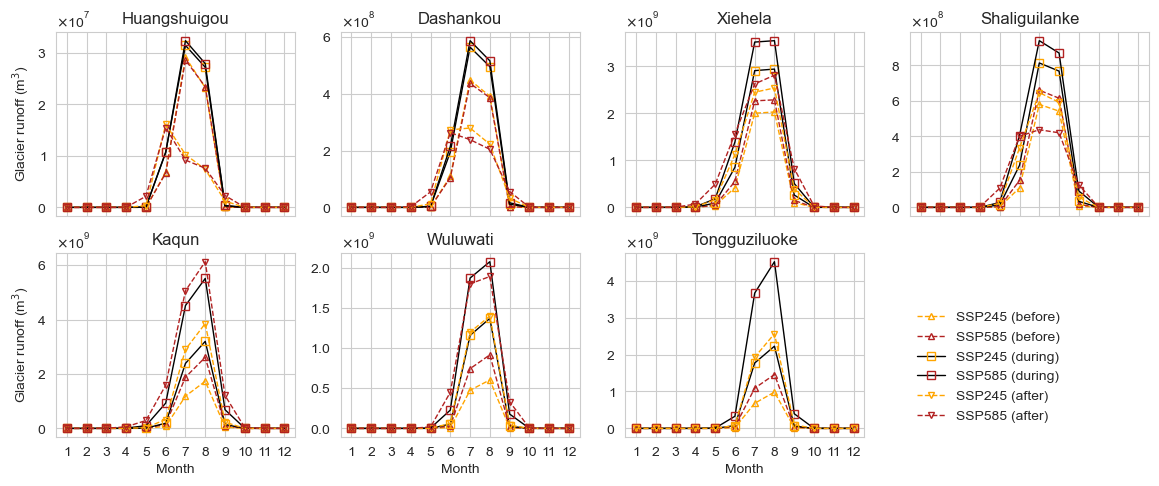

In [81]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Example color list
station_monthly_gr_dfs = {
    station: monthly_gr_df[['time', 'scenario', 'month', 'year', station]].pivot(
        index='time', columns='scenario', values=station
    )
    for station in stations
}

# Ensure the 'time' index is datetime for month extraction
for df in station_monthly_gr_dfs.values():
    df.index = pd.to_datetime(df.index)

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()

# Remove the unused subplot
fig.delaxes(axes[-1])

for ii, (station, station_monthly_gr_df) in enumerate(station_monthly_gr_dfs.items()):
    print(station_names[ii])
    ax = axes[ii]

    # Set scientific notation for the y-axis
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # Forces scientific notation

    # Set the y-label with proper formatting
    ax.set_ylabel(r'Glacier runoff (m$^3$)')

    # Adjust the position of the scientific notation exponent
    ax.yaxis.get_offset_text().set_fontsize(10)  # Adjust font size if needed

    # Add the month column
    station_monthly_gr_df['month'] = station_monthly_gr_df.index.month

    # Plot the data for the 'before' period
    for i, scenario in enumerate(['ssp245', 'ssp585']):
        # Calculate mean monthly values for the two periods
        station_mean_mon_gr_df_before = (
            station_monthly_gr_df[station_monthly_gr_df.index <= str(peak_water_df.iloc[ii,i]-15)]
            .groupby('month')
            .mean()
        )
        ax.plot(
            station_mean_mon_gr_df_before.index,
            station_mean_mon_gr_df_before[scenario],
            label=f"{scenario.upper()} (before)",
            color=color_list[i % len(color_list) *2 +1],
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

    # Plot the data for the 'during' period
    for i, scenario in enumerate(['ssp245', 'ssp585']):

        # Convert the peak water year to a datetime object for comparison
        peak_year = pd.to_datetime(peak_water_df.iloc[ii, i], format='%Y')

        # Perform the comparison using datetime objects
        station_mean_mon_gr_df_during = (
            station_monthly_gr_df[(station_monthly_gr_df.index >= peak_year - pd.DateOffset(years=15)) &
                                  (station_monthly_gr_df.index < peak_year + pd.DateOffset(years=15))]
            .groupby('month')
            .mean()
        )

        ax.plot(
            station_mean_mon_gr_df_during.index,
            station_mean_mon_gr_df_during[scenario],
            label=f"{scenario.upper()} (during)",
            color='black',
            marker="s",        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            markeredgecolor=color_list[i % len(color_list) *2 +1], # Marker edge color
            linestyle='-',
            linewidth=1,
            markersize=6
        )

        print(station, scenario,1- station_mean_mon_gr_df_after.loc[6:8,scenario].mean() / station_mean_mon_gr_df_before.loc[6:8,scenario].mean() )
    # Plot the data for the 'after' period
    for i, scenario in enumerate(['ssp245', 'ssp585']):

        if peak_water_df.iloc[ii,i]<2080:

            station_mean_mon_gr_df_after = (
                station_monthly_gr_df[station_monthly_gr_df.index >= str(peak_water_df.iloc[ii,i]+15)]
                .groupby('month')
                .mean()
            )
            ax.plot(
                station_mean_mon_gr_df_after.index,
                station_mean_mon_gr_df_after[scenario],
                label=f"{scenario.upper()} (after)",
                color=color_list[i % len(color_list) *2 +1],
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=1,
                markersize=5
            )


    # print(station, scenario,1- station_mean_mon_gr_df_after.mean() / station_mean_mon_gr_df_before.mean() )

    # Add labels, title, and grid
    ax.set_title(station)
    ax.set_ylabel('Glacier runoff (m$^3$)')
    ax.set_xticks(range(1, 13))  # Assuming months 1-12
    ax.grid(True)
    ax.legend(fontsize='small')

    # Remove y-axis labels for the 2nd column
    if ii % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        axes[ii].set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if ii < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        axes[ii].set_xlabel('')  # Remove the x-axis label
        axes[ii].set_xticklabels([])
    else:
        axes[ii].set_xlabel('Month')
    # ax.set_ylim(bottom = 0,top = 100)

    ax.set_title(station_names[ii])

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# fig.suptitle('Monthly Glacier Runoff Before and After Peak Water', fontsize=16)
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure3_1_SSP245_SSP585.svg')
plt.show()



In [75]:
peak_water_df.iloc[ii,i]

np.int64(2080)

hsg scenario
ssp126   -0.416229
ssp245   -0.410071
ssp370   -0.389146
ssp585   -0.372047
dtype: float64
dsk scenario
ssp126   -0.235882
ssp245   -0.232036
ssp370   -0.198862
ssp585   -0.215476
dtype: float64
xhl scenario
ssp126    0.019720
ssp245    0.300479
ssp370    0.585295
ssp585    0.693282
dtype: float64
slglk scenario
ssp126   -0.126740
ssp245    0.030862
ssp370    0.060156
ssp585   -0.070262
dtype: float64
kq scenario
ssp126    0.201409
ssp245    0.899146
ssp370    1.804986
ssp585    1.974150
dtype: float64
wlwt scenario
ssp126   -0.016812
ssp245    0.655826
ssp370    1.648643
ssp585    1.156224
dtype: float64
tgzlk scenario
ssp126    0.249455
ssp245    1.020376
ssp370    2.376278
ssp585    2.659181
dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_54080\2818661354.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


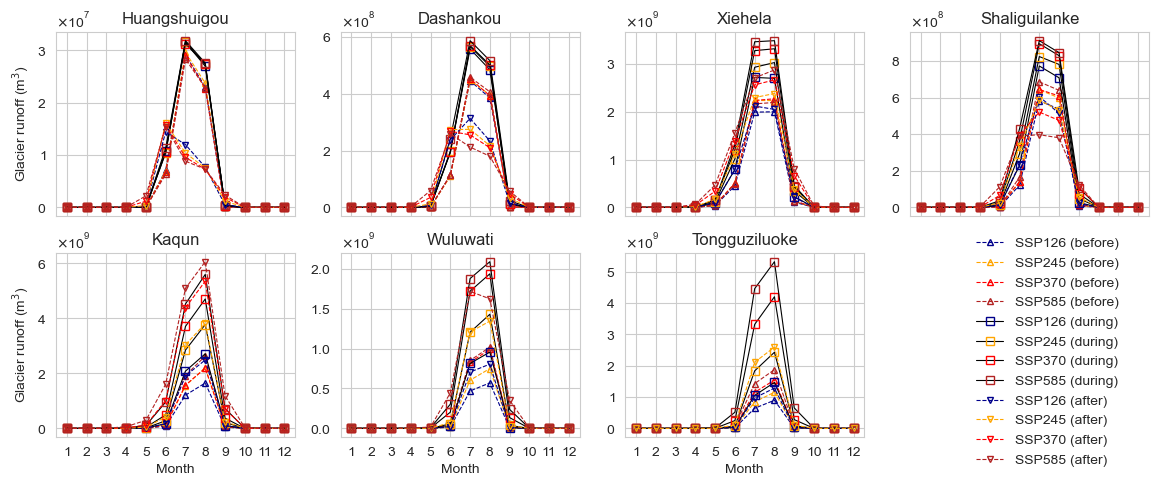

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Example color list
station_monthly_gr_dfs = {
    station: monthly_gr_df[['time', 'scenario', 'month', 'year', station]].pivot(
        index='time', columns='scenario', values=station
    )
    for station in stations
}

# Ensure the 'time' index is datetime for month extraction
for df in station_monthly_gr_dfs.values():
    df.index = pd.to_datetime(df.index)

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()

# Remove the unused subplot
fig.delaxes(axes[-1])

for ii, (station, station_monthly_gr_df) in enumerate(station_monthly_gr_dfs.items()):
    ax = axes[ii]

    # Set scientific notation for the y-axis
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # Forces scientific notation

    # Set the y-label with proper formatting
    ax.set_ylabel(r'Glacier runoff (m$^3$)')

    # Adjust the position of the scientific notation exponent
    ax.yaxis.get_offset_text().set_fontsize(10)  # Adjust font size if needed

    # Add the month column
    station_monthly_gr_df['month'] = station_monthly_gr_df.index.month

    # Plot the data for the 'before' period
    for i, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        # Calculate mean monthly values for the two periods
        station_mean_mon_gr_df_before = (
            station_monthly_gr_df[station_monthly_gr_df.index <= str(peak_water_df.iloc[ii,i]-15)]
            .groupby('month')
            .mean()
        )
        ax.plot(
            station_mean_mon_gr_df_before.index,
            station_mean_mon_gr_df_before[scenario],
            label=f"{scenario.upper()} (before)",
            color=color_list[i % len(color_list)],
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=0.8,
            markersize=5
        )

# Plot the data for the 'during' period
    for i, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):

        # Convert the peak water year to a datetime object for comparison
        peak_year = pd.to_datetime(peak_water_df.iloc[ii, i], format='%Y')

        # Perform the comparison using datetime objects
        station_mean_mon_gr_df_during = (
            station_monthly_gr_df[(station_monthly_gr_df.index >= peak_year - pd.DateOffset(years=15)) &
                                  (station_monthly_gr_df.index < peak_year + pd.DateOffset(years=15))]
            .groupby('month')
            .mean()
        )

        ax.plot(
            station_mean_mon_gr_df_during.index,
            station_mean_mon_gr_df_during[scenario],
            label=f"{scenario.upper()} (during)",
            marker="s",        # Use dots
            color='black',    # Set the face color to none for hollow effect
            markerfacecolor='none',
            markeredgecolor=color_list[i % len(color_list)],        # Edge color of the marker
            linestyle='-',
            linewidth=0.8,
            markersize=6
        )

        # print(station, scenario,station_mean_mon_gr_df_during.loc[6:8,scenario].mean() / station_mean_mon_gr_df_after.loc[6:8,scenario].mean() -1)
    # Plot the data for the 'after' period
    for i, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        if peak_water_df.iloc[ii,i]<2090:
            station_mean_mon_gr_df_after = (
                station_monthly_gr_df[station_monthly_gr_df.index >= str(peak_water_df.iloc[ii,i]+15)]
                .groupby('month')
                .mean()
            )
            ax.plot(
                station_mean_mon_gr_df_after.index,
                station_mean_mon_gr_df_after[scenario],
                label=f"{scenario.upper()} (after)",
                color=color_list[i % len(color_list)],
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=0.8,
                markersize=5
            )


    print(station,station_mean_mon_gr_df_after.mean() / station_mean_mon_gr_df_before.mean() -1)

    # Add labels, title, and grid
    ax.set_title(station)
    ax.set_ylabel('Glacier runoff (m$^3$)')
    ax.set_xticks(range(1, 13))  # Assuming months 1-12
    ax.grid(True)
    ax.legend(fontsize='small')

    # Remove y-axis labels for the 2nd column
    if ii % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        axes[ii].set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if ii < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        axes[ii].set_xlabel('')  # Remove the x-axis label
        axes[ii].set_xticklabels([])
    else:
        axes[ii].set_xlabel('Month')
    # ax.set_ylim(bottom = 0,top = 100)

    ax.set_title(station_names[ii])

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.9, 0.28), bbox_transform=fig.transFigure)

# fig.suptitle('Monthly Glacier Runoff Before and After Peak Water', fontsize=16)
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure3_1.svg')
plt.show()



In [22]:
ax.yaxis.get_offset_text()

Text(0, 0.5, '')

In [23]:
station_mean_mon_gr_df_after.loc[6:8,scenario]

Series([], Name: ssp585, dtype: float64)

In [24]:
peak_water_df.iloc[ii,i]

np.int64(2094)

hsg scenario
ssp126    0.770827
ssp245    0.761661
ssp370    0.754949
ssp585    0.744343
dtype: float64
dsk scenario
ssp126    0.720956
ssp245    0.726433
ssp370    0.726798
ssp585    0.717997
dtype: float64
xhl scenario
ssp126    0.492666
ssp245    0.350970
ssp370    0.194082
ssp585    0.126532
dtype: float64
slglk scenario
ssp126    0.522353
ssp245    0.459216
ssp370    0.465293
ssp585    0.523343
dtype: float64
kq scenario
ssp126    0.104466
ssp245   -0.463900
ssp370   -1.193439
ssp585   -1.754849
dtype: float64
wlwt scenario
ssp126   -0.066923
ssp245   -0.827446
ssp370   -1.757616
ssp585   -2.204293
dtype: float64
tgzlk scenario
ssp126   -0.108667
ssp245   -1.189595
ssp370   -2.915219
ssp585   -4.493099
dtype: float64


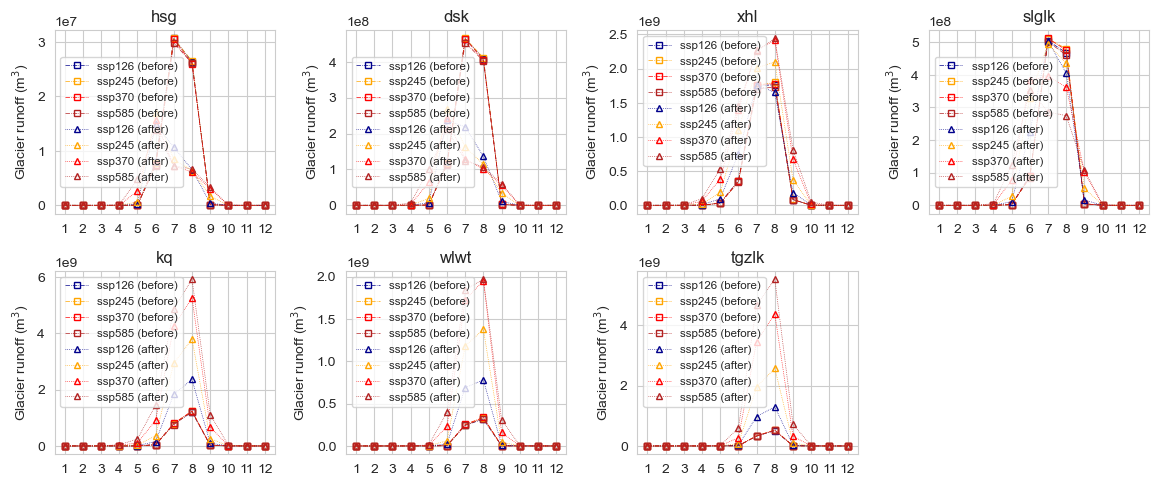

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Example color list
station_monthly_gr_dfs = {
    station: monthly_gr_df[['time', 'scenario', 'month', 'year', station]].pivot(
        index='time', columns='scenario', values=station
    )
    for station in stations
}

# Ensure the 'time' index is datetime for month extraction
for df in station_monthly_gr_dfs.values():
    df.index = pd.to_datetime(df.index)

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()

# Remove the unused subplot
fig.delaxes(axes[-1])

for ii, (station, station_monthly_gr_df) in enumerate(station_monthly_gr_dfs.items()):
    ax = axes[ii]

    # Add the month column
    station_monthly_gr_df['month'] = station_monthly_gr_df.index.month

    # Calculate mean monthly values for the two periods
    station_mean_mon_gr_df_before = (
        station_monthly_gr_df[station_monthly_gr_df.index <= '2015-12-31']
        .groupby('month')
        .mean()
    )
    station_mean_mon_gr_df_after = (
        station_monthly_gr_df[station_monthly_gr_df.index >= '2085-01-01']
        .groupby('month')
        .mean()
    )

    # Plot the data for the 'before' period
    for i, scenario in enumerate(station_mean_mon_gr_df_before.columns):
        ax.plot(
            station_mean_mon_gr_df_before.index,
            station_mean_mon_gr_df_before[scenario],
            label=f"{scenario} (before)",
            color=color_list[i % len(color_list)],
            marker='s',
            markerfacecolor='none',
            linestyle='dashdot',
            linewidth=0.5,
            markersize=5,
        )

    # Plot the data for the 'after' period
    for i, scenario in enumerate(station_mean_mon_gr_df_after.columns):
        ax.plot(
            station_mean_mon_gr_df_after.index,
            station_mean_mon_gr_df_after[scenario],
            label=f"{scenario} (after)",
            color=color_list[i % len(color_list)],
            marker='^',
            markerfacecolor='none',
            linestyle='dotted',
            linewidth=0.5,
            markersize=5,
        )

    # Add labels, title, and grid
    ax.set_title(station)
    ax.set_ylabel('Glacier runoff (m$^3$)')
    ax.set_xticks(range(1, 13))  # Assuming months 1-12
    ax.grid(True)
    ax.legend(fontsize='small')

    print(station, 1 - station_mean_mon_gr_df_after[4:9].mean()/station_mean_mon_gr_df_before[6:8].mean() )

# Adjust layout and save the figure
plt.tight_layout()
# plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure3_1.svg')
plt.show()


In [26]:
station_monthly_gr_df[station_monthly_gr_df.index<= '2015-12-31'].groupby('month').mean()

scenario,ssp126,ssp245,ssp370,ssp585
month,,,,
1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,5.034698e+00,5.484121e+00,1.091573e+00,2.196296e+00
5,3.655761e+04,5.374116e+04,3.511714e+04,3.051180e+04
6,7.554293e+06,7.601296e+06,7.262906e+06,7.232986e+06
7,3.304268e+08,3.350588e+08,3.328853e+08,3.234091e+08
8,5.062482e+08,5.233962e+08,5.276526e+08,5.147039e+08
9,4.787175e+06,5.079064e+06,5.420939e+06,4.985525e+06


In [27]:
os.chdir(r"K:\GlacierData\glacier_mon_pre")

In [28]:
os.listdir()

['glacier_mon_pre.zip',
 'glacier_peak_water.csv',
 'model0R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp126-Batch.csv',
 'model0R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp245-Batch.csv',
 'model0R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp370-Batch.csv',
 'model0R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp585-Batch.csv',
 'model10R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp126-Batch.csv',
 'model10R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp245-Batch.csv',
 'model10R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp370-Batch.csv',
 'model10R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp585-Batch.csv',
 'model11R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp126-Batch.csv',
 'model11R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp245-Batch.csv',
 'model11R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp370-Batch.csv',
 'model11R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp585-Batch.csv',
 'model1R131415_glac_runoff_f

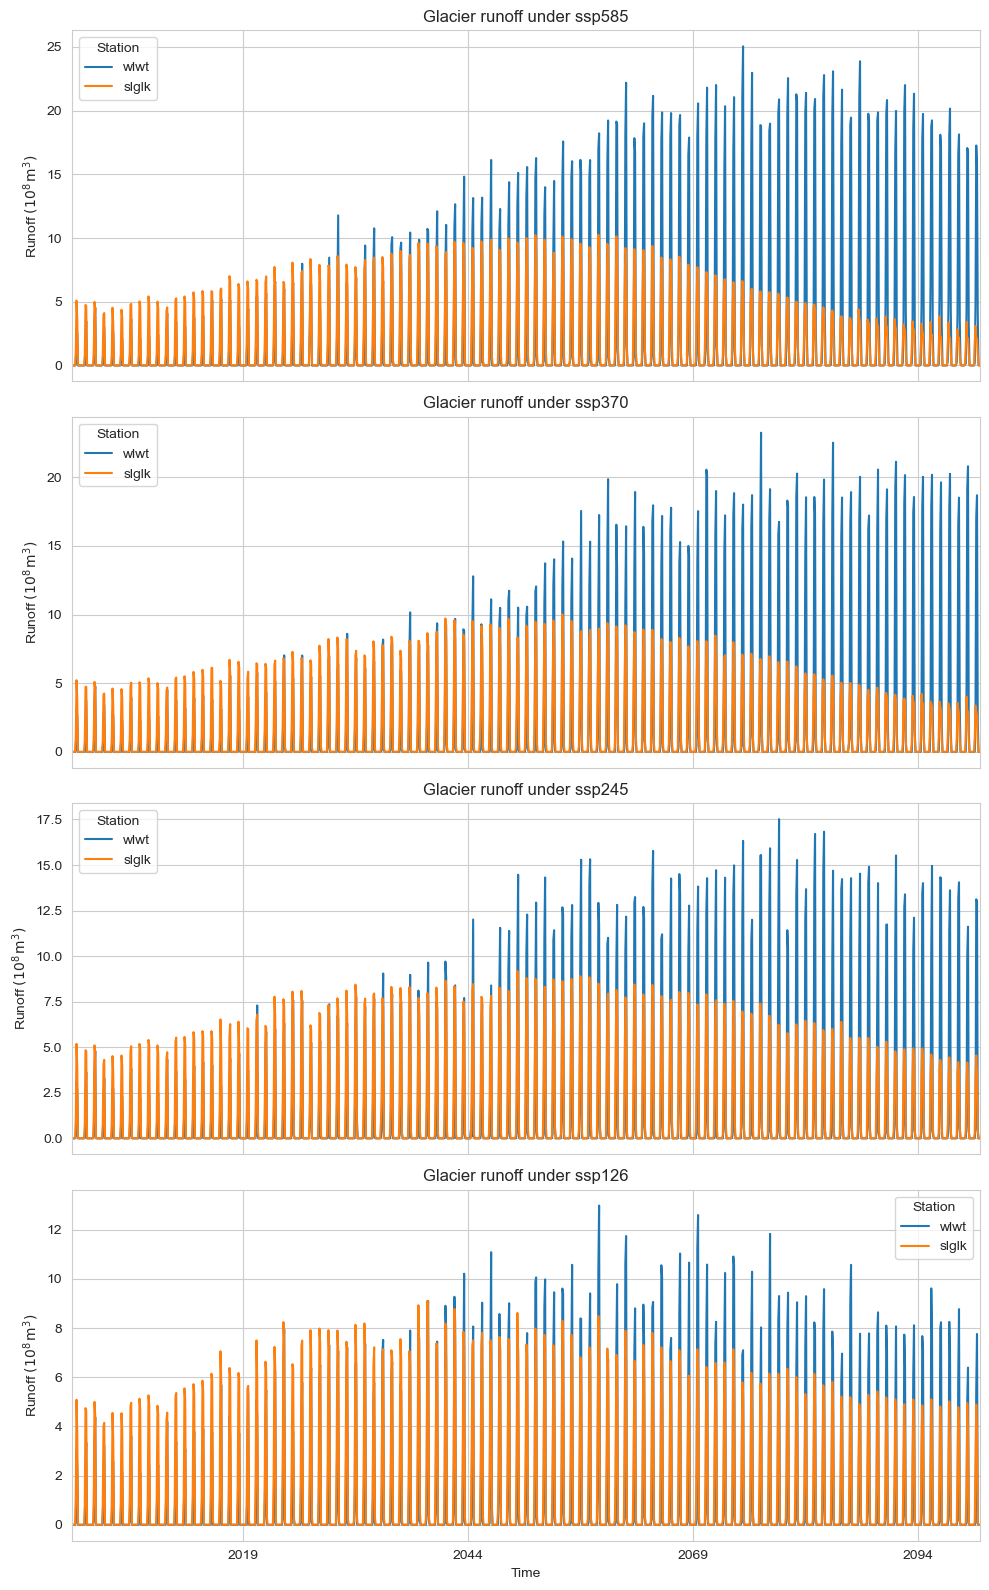

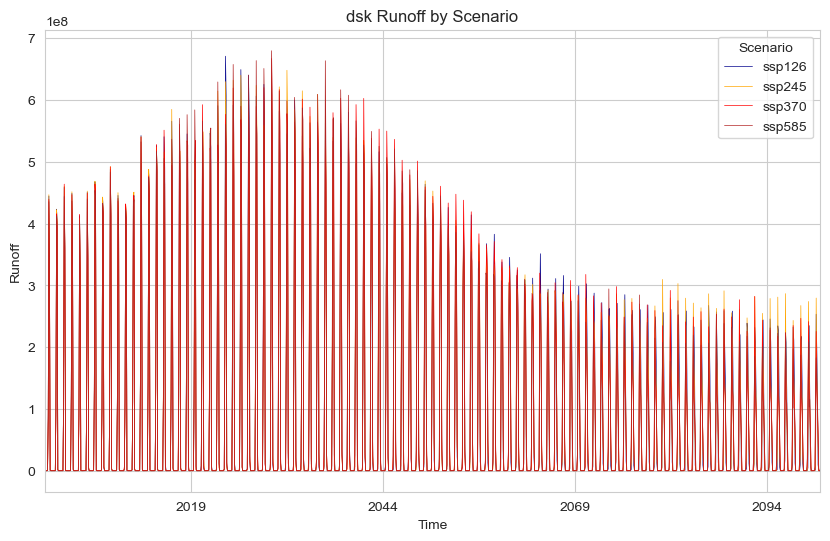

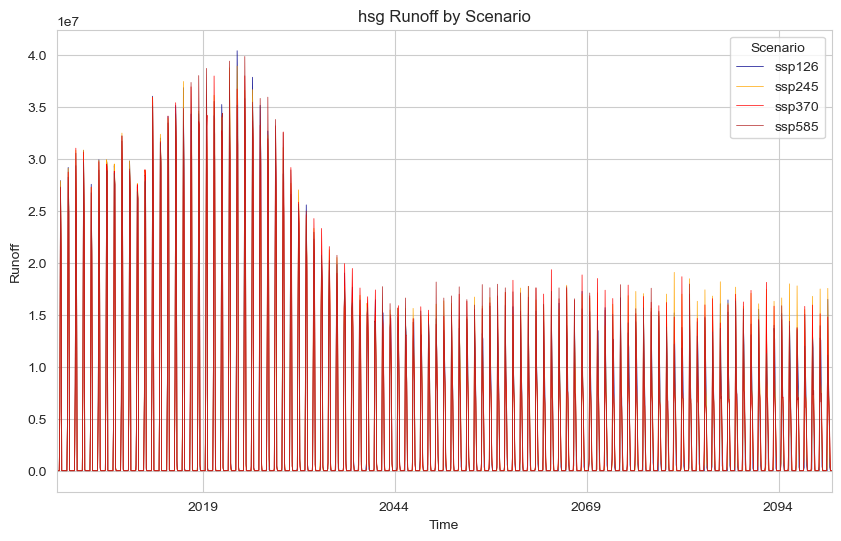

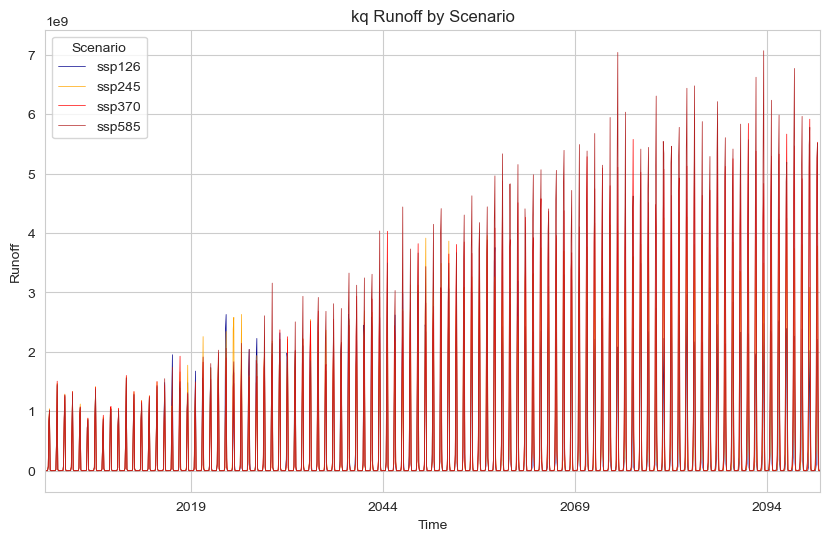

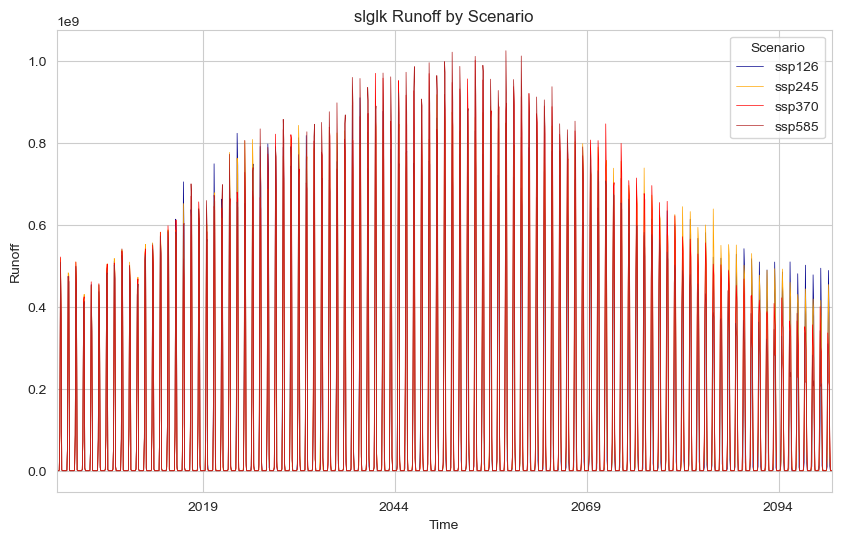

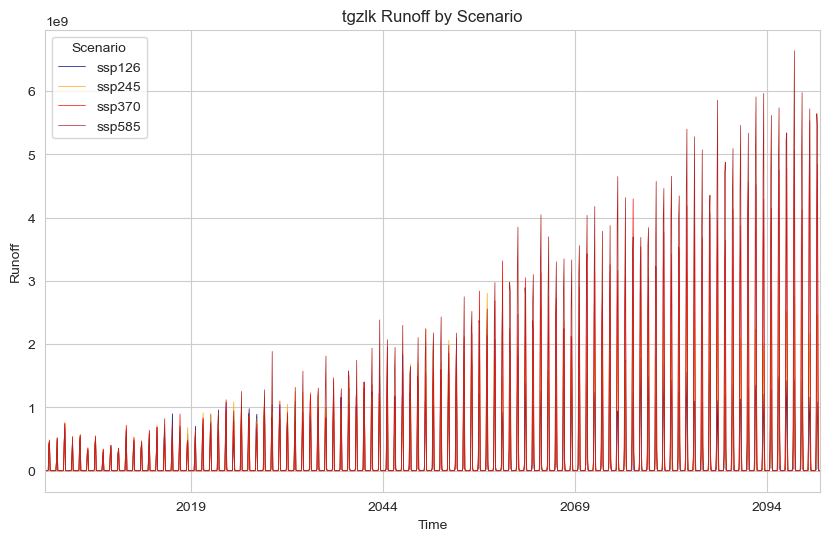

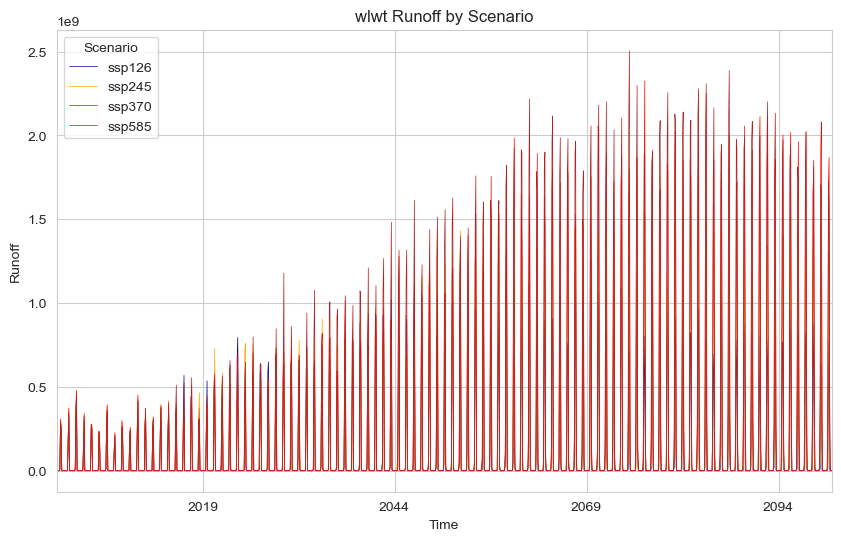

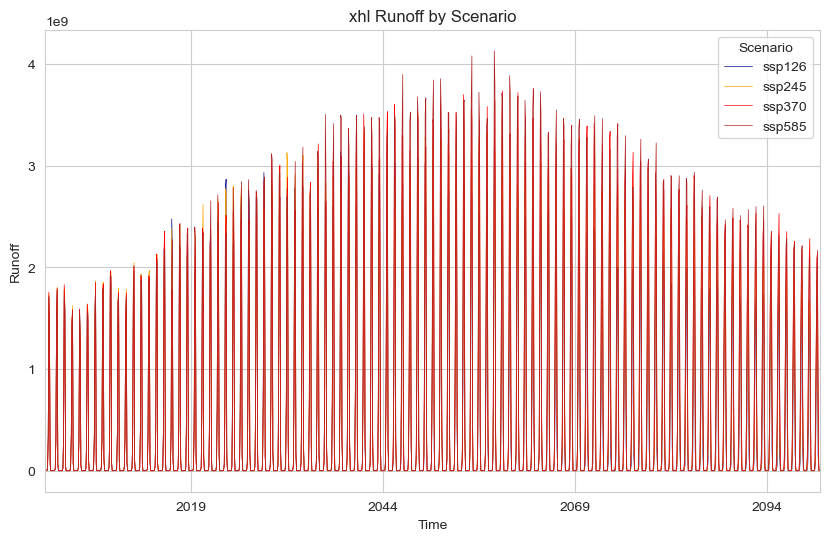

In [29]:
monthly_ssp_gr_df=  pd.concat(
    [pd.read_csv(f"R131415_glac_runoff_fixed_monthly_1set_2000_2100-{scenario}-Batch.csv")
     .assign(scenario=scenario) for scenario in ['ssp585', 'ssp370', 'ssp245', 'ssp126']],
    ignore_index=True
)
# Create a figure with 4 stacked subplots (1 column, 4 rows)
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

# Loop through each scenario and plot in its corresponding subplot
for i, scenario in enumerate(['ssp585', 'ssp370', 'ssp245', 'ssp126']):
    ax = axes[i]
    rcp_gr_df = monthly_ssp_gr_df[monthly_ssp_gr_df['scenario'] == scenario][['wlwt', 'slglk']] 
    rcp_gr_df.index = pd.date_range(start="2000-01", end="2101-01", freq="ME")
    (rcp_gr_df/ 1e8).plot(ax=ax)
    ax.set_title(f"Glacier runoff under {scenario}")
    ax.set_xlabel("Time")
    ax.set_ylabel(r"Runoff $(10^{8} \, \mathrm{m}^{3})$")
    ax.legend(title="Station")
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

for station in monthly_ssp_gr_df.columns[1:-1]:
    station_ssp_gr_df = monthly_ssp_gr_df.pivot(index='time', columns='scenario', values=station)
    station_ssp_gr_df.index = pd.to_datetime(station_ssp_gr_df.index)
    
    # Plot with the custom color list
    station_ssp_gr_df.plot(color=color_list, figsize=(10, 6), linewidth=0.5)
    plt.title(f"{station} Runoff by Scenario")
    plt.xlabel("Time")
    plt.ylabel("Runoff")
    plt.legend(title="Scenario")
    plt.grid(True)
    plt.show()

In [30]:
print(monthly_ssp_gr_df)

            time           dsk           hsg            kq         slglk  \
0     2000-01-31  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
1     2000-02-29  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
2     2000-03-31  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
3     2000-04-30  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
4     2000-05-31  5.392457e+05  8.064847e+02  4.488206e+05  1.248940e+06   
...          ...           ...           ...           ...           ...   
4843  2100-08-31  1.235619e+08  6.017204e+06  2.211005e+09  3.850169e+08   
4844  2100-09-30  9.766779e+06  3.260695e+05  1.091823e+08  1.157297e+07   
4845  2100-10-31  0.000000e+00  0.000000e+00  5.128888e+01  0.000000e+00   
4846  2100-11-30  0.000000e+00  0.000000e+00  2.823421e+02  0.000000e+00   
4847  2100-12-31  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   

             tgzlk          wlwt           xhl scenario  
0     0.000000e+00  0.000000e

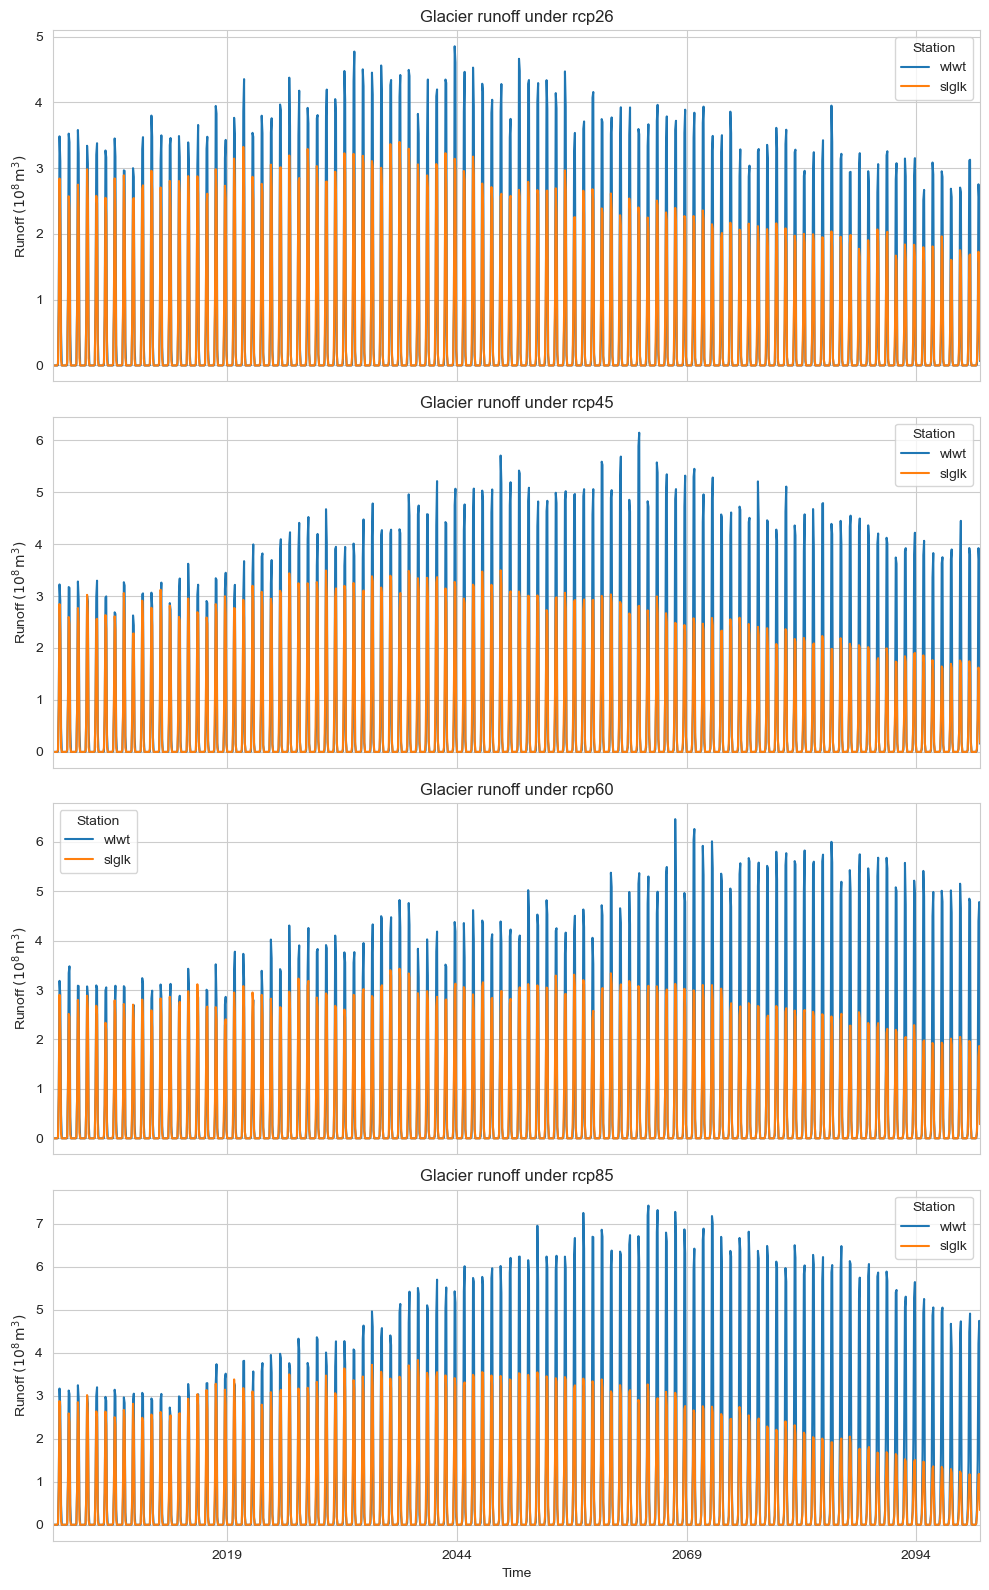

KeyError: 'time'

In [31]:
monthly_rcp_gr_df=  pd.concat(
    [pd.read_csv(f"R131415_glac_runoff_fixed_monthly_1set_2000_2100-{scenario}-Batch.csv")
     .assign(scenario=scenario) for scenario in ['rcp26', 'rcp45', 'rcp60', 'rcp85']],
    ignore_index=True
)
# Create a figure with 4 stacked subplots (1 column, 4 rows)
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

# Loop through each scenario and plot in its corresponding subplot
for i, scenario in enumerate(['rcp26', 'rcp45', 'rcp60', 'rcp85']):
    ax = axes[i]
    rcp_gr_df = monthly_rcp_gr_df[monthly_rcp_gr_df['scenario'] == scenario][['wlwt', 'slglk']] 
    
    rcp_gr_df.index = pd.date_range(start="2000-01", end="2101-01", freq="ME")
    # rcp_gr_df['year'] = rcp_gr_df.index.year
    # rcp_gr__ann_df = rcp_gr_df.groupby(['year']).sum()
    (rcp_gr_df/ 1e8).plot(ax=ax)
    ax.set_title(f"Glacier runoff under {scenario}")
    ax.set_xlabel("Time")
    ax.set_ylabel(r"Runoff $(10^{8} \, \mathrm{m}^{3})$")
    ax.legend(title="Station")
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()


for station in monthly_rcp_gr_df.columns[1:-1]:
    station_rcp_gr_df = monthly_rcp_gr_df.pivot(index='time', columns='scenario', values=station)
    station_rcp_gr_df.index = pd.to_datetime(station_rcp_gr_df.index)
    
    # Plot with the custom color list
    station_rcp_gr_df.plot(color=color_list, figsize=(10, 6), linewidth=0.5)
    plt.title(f"{station} Runoff by Scenario")
    plt.xlabel("Time")
    plt.ylabel("Runoff")
    plt.legend(title="Scenario")
    plt.grid(True)
    plt.show()

In [ ]:
monthly_ssp_rcp_gr_df=  pd.concat(
    [pd.read_csv(f"R131415_glac_runoff_fixed_monthly_1set_2000_2100-{scenario}-Batch.csv")
     .assign(scenario=scenario) for scenario in [ 'ssp126','rcp26','ssp245', 'rcp45', 'rcp60','ssp370', 'rcp85','ssp585']],
    ignore_index=True
)
# Create a figure with 4 stacked subplots (1 column, 4 rows)
fig, axes = plt.subplots(8, 1, figsize=(10, 16), sharex=True)

# Loop through each scenario and plot in its corresponding subplot
for i, scenario in enumerate([ 'ssp126','rcp26','ssp245', 'rcp45', 'rcp60','ssp370', 'rcp85','ssp585']):
    ax = axes[i]
    ssp_rcp_gr_df = monthly_ssp_rcp_gr_df[monthly_ssp_rcp_gr_df['scenario'] == scenario][['wlwt', 'slglk']] 
    ssp_rcp_gr_df.index = pd.date_range(start="2000-01", end="2101-01", freq="ME")
    ssp_rcp_gr_df['year'] = rcp_gr_df.index.year
    ssp_rcp_gr_ann_df = rcp_gr_df.groupby(['year']).sum()
    (ssp_rcp_gr_ann_df/ 1e8).plot(ax=ax)
    # (ssp_rcp_gr_df/ 1e8).plot(ax=ax)
    ax.set_title(f"Glacier runoff under {scenario}")
    ax.set_xlabel("Time")
    ax.set_ylabel(r"Runoff $(10^{8} \, \mathrm{m}^{3})$")
    ax.set_ylim(bottom=0,top=20)
    ax.legend(title="Station")
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()


for station in monthly_ssp_rcp_gr_df.columns[1:-1]:
    station_ssp_rcp_gr_df = monthly_ssp_rcp_gr_df.pivot(index='time', columns='scenario', values=station)
    station_ssp_rcp_gr_df.index = pd.to_datetime(station_ssp_rcp_gr_df.index)
    
    # Plot with the custom color list
    station_ssp_rcp_gr_df.plot(color=color_list, figsize=(10, 6), linewidth=0.5)
    plt.title(f"{station} Runoff by Scenario")
    plt.xlabel("Time")
    plt.ylabel("Runoff")
    plt.legend(title="Scenario")
    plt.grid(True)
    plt.show()

In [ ]:
# Create a figure with 4 stacked subplots (1 column, 4 rows)
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)
for i,scenario in enumerate(['ssp126','ssp245','ssp370','ssp585']):
    print(scenario)
    ax = axes[i]
    station_mean_oggm_annual_gr_df=pd.read_csv(f"K:\\High_Mountain_Asia_OGGM_Glacier_Projections\\future\\station_future_2022_2100_mri-esm2-0_{scenario}_elv.csv",index_col=0)
    station_mean_oggm_annual_gr_df.index = pd.to_datetime(station_mean_oggm_annual_gr_df.index)
    station_mean_oggm_annual_gr_df[['wlwt','slglk']].plot(ax=ax)
    
    ax.set_title(f"Glacier runoff under {scenario}")
    ax.set_xlabel("Time")
    ax.set_ylabel(r"Runoff $(10^{8} \, \mathrm{m}^{3})$")
    # ax.set_ylim(bottom=0,top=20)
    ax.legend(title="Station")
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()
plt.show()    